In [2]:
import matplotlib.pyplot as plt
import json
import matplotlib.ticker as ticker
def read_json(file_path):
    import json
    with open(file_path, "r") as f:
        action_time_history = json.load(f)
        # 将字符串key转换为int
        converted_history = {}
        for action_str in   action_time_history:
            action_int = int(action_str)
            converted_history[action_int] = {}
            for batch_str in action_time_history[action_str]:
                batch_int = int(batch_str)
                converted_history[action_int][batch_int] = action_time_history[action_str][batch_str]
                for i in range(2):
                    # 这样就会多出两个，一共四个，前两个是str 后两个是int
                    converted_history[action_int][batch_int][int(i)] = action_time_history[action_str][batch_str][str(i)]
        action_time_history = converted_history
    return action_time_history
def read_log(file_path):
    # 读取JSON文件
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    org_throughput = []
    org_e2e = []
    # 如果data是列表，可以直接遍历
    for item in data:
        org_throughput.append(item["total_token_throughput"])
        org_e2e.append(item["mean_e2el_ms"])
    return org_throughput,org_e2e
def common_plt(plt,xs,datas,names,xlabel='Request Rate (QPS)',ylabel='Total Token throughput (tok/s)',title='Throughput vs QPS',save_path=None):
    plottext=['o-','s-','x-','^-','v-','d-','p-','h-','*--','x--','o--','s--','^-','v--','d--','p--','h--','*--']
    plt.figure(figsize=(8, 6))
    for index, data in enumerate(datas):
        plt.plot(xs, data, plottext[index], linewidth=3, markersize=12, label=names[index])
    plt.xlabel(xlabel, fontsize=22, fontweight='bold')
    plt.ylabel(ylabel, fontsize=22, fontweight='bold')
    plt.title(title, fontsize=26, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    # Make axis ticks sparser
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))  # At most 6 x-ticks
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))  # At most 6 y-ticks

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', pad_inches=0)
    plt.show()
    # for index, data in enumerate(datas):
    #     plt.plot(xs, data, plottext[index], linewidth=2, markersize=8, label=names[index])
    # plt.xlabel(xlabel, fontsize=16, fontweight='bold')
    # plt.ylabel(ylabel, fontsize=16, fontweight='bold')
    # plt.title(title, fontsize=18, fontweight='bold')
    # # plt.xlabel('Request Rate (QPS)', fontsize=16, fontweight='bold')
    # # plt.ylabel('Total Token throughput (tok/s)', fontsize=16, fontweight='bold')
    # # plt.title('Throughput vs QPS', fontsize=18, fontweight='bold')
    # # 设置网格，让图表更清晰
    # plt.grid(True, linestyle='--', alpha=0.7)

    # # 设置图例，使用大字体
    # plt.legend(fontsize=14)

    # # 设置坐标轴刻度字体大小
    # plt.xticks(fontsize=14)
    # plt.yticks(fontsize=14)

    # # 调整布局，使图形更紧凑
    # plt.tight_layout()
    # if save_path:
    #     plt.savefig(save_path, dpi=400, bbox_inches='tight', pad_inches=0)
    # # 显示图形
    # plt.show()

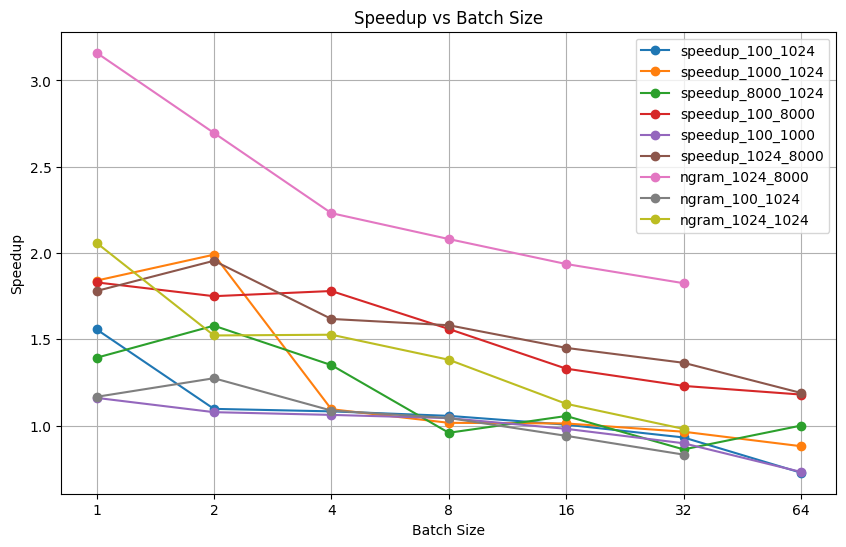

In [2]:
batch = [1,2,4,8,16,32,64]
num_speculative_tokens=4,
speedup_100=[1.5579658421945792, 1.0970094984765753, 1.082549661495246, 1.0564554301736515, 1.005463394256355, 0.9312970632089327, 0.7269783718269229, 0.6312932499701492]
#speedup_100=[1.06,1.11,1.08,1.06,0.98,0.94,0.73,0.65]
speedup_1000= [1.8402744572271694, 1.9905473508275913, 1.095023935376927, 1.016176018665192, 1.0125342406631515, 0.9645324286023979, 0.8806274049115759, 0.8659458876325434]
#speedup_1000=[1.5276811544444473, 1.5127895268729383, 1.7940301177722615, 1.6315347476228224, 1.0739863406552894, 0.9916740841876358, 0.8731921079029183, 0.945087080599881]
speedup_8000=[1.3931953623037874, 1.5790655148141, 1.3506058725473074, 0.9584640571147828, 1.0556605081435158, 0.8620243972971677, 1.0002209228365968, 0.9738580841080994]
speedup_100_8000=[1.83,1.75,1.78,1.56, 1.33,1.23,1.18]
speedup_100_1000=[1.1607102634738782, 1.0778975750119, 1.062046635036074, 1.0434490766438977, 0.9813152786947341, 0.8976552114670254, 0.7314690013674334]
speedup_1024_8000=[1.780068728639024, 1.9552658961701876, 1.618107814528487, 1.5816858001647156, 1.4503813734237543, 1.3640501439957755, 1.1891814697159526]
#speedup_8000=[1.33,1.01,1.36,1.02,1.04,0.92,0.99,0.95]
# speedup_9000=[1.0637111235052408, 0.8585515852014719, 0.692895231104329, 0.4939649556522406, 0.5702005268437915, 0.6551350348360595, 0.6119091070937024, 0.6089015290117911]
# speedup_9000=[2.71,2.83,1.15,1.13,1.26,1.20,1.33,1.19]
# speedup_10000=[944.6302540964142, 569.7925180700602, 1.5142904318073478, 1.4083259496542093, 2.4489820196485343, 2.2580635316248143, 2.4627876676006015, 2.0913348395636704]
ngram_1024_8000=[3.16088887255521, 2.6960308445723733, 2.2312504366585397, 2.081106071793124, 1.9363554664480214, 1.8252739503191742]
ngram_100_1024=[1.166743951894817, 1.2745298237349114, 1.0871856808359686, 1.0439035018558565, 0.9407077036717523, 0.8319042281159736]
ngram_1024_1024=[2.05916211219563, 1.5224284427329258, 1.5266896546495716, 1.3817029144976214, 1.1263408274202928, 0.9809073943233543]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(batch, speedup_100[:-1], marker='o', label='speedup_100_1024')
plt.plot(batch, speedup_1000[:-1], marker='o', label='speedup_1000_1024')
plt.plot(batch, speedup_8000[:-1], marker='o', label='speedup_8000_1024')
plt.plot(batch, speedup_100_8000, marker='o', label='speedup_100_8000')
plt.plot(batch, speedup_100_1000, marker='o', label='speedup_100_1000')
plt.plot(batch, speedup_1024_8000, marker='o', label='speedup_1024_8000')
plt.plot(batch[:-1], ngram_1024_8000, marker='o', label='ngram_1024_8000')
plt.plot(batch[:-1], ngram_100_1024, marker='o', label='ngram_100_1024')
plt.plot(batch[:-1], ngram_1024_1024, marker='o', label='ngram_1024_1024')
plt.xscale('log', base=2)

plt.xticks(batch, batch)

plt.xlabel('Batch Size')
plt.ylabel('Speedup')
plt.title('Speedup vs Batch Size')
plt.grid(True)
plt.legend()
plt.savefig('speedup_vs_batch_size.png')

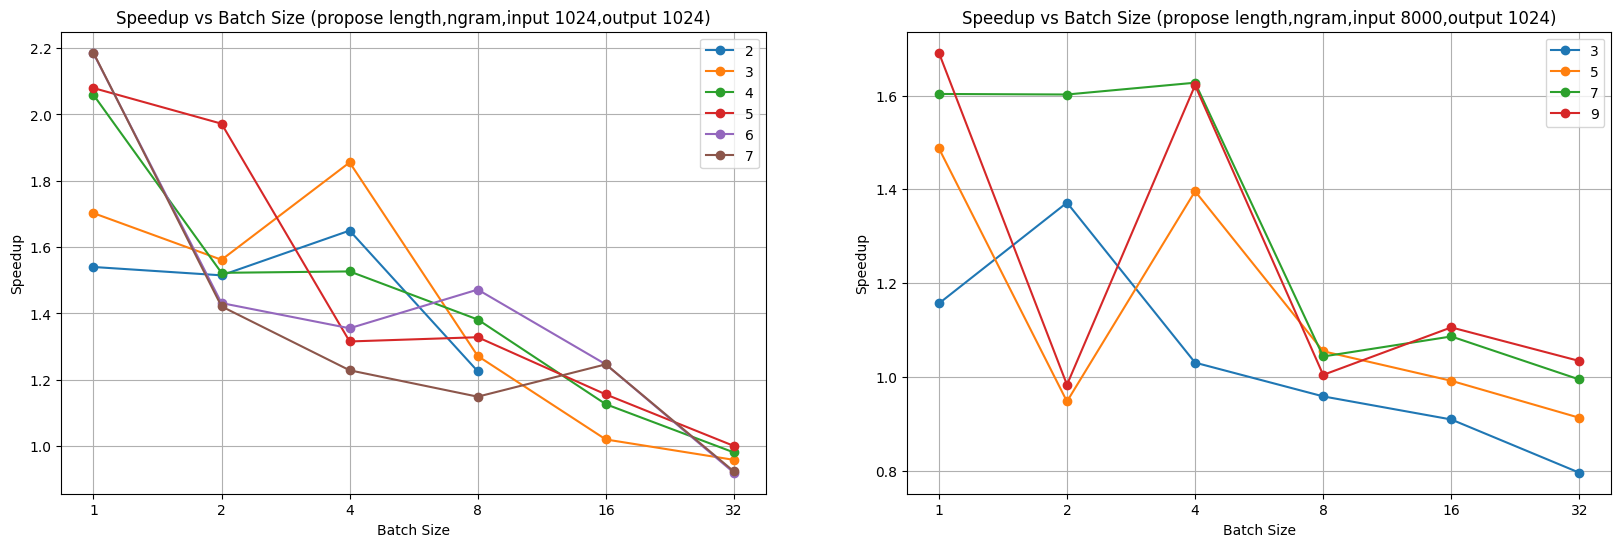

In [3]:
batch = [1,2,4,8,16,32]
num_speculative_tokens=4,
ngram_prompt_lookup_max=2,
ngram_1024_1024_small_memory_lookup_max_2=[1.7908452866445732, 1.4707481668104323, 1.2951955416011136, 1.2559043175403917]
ngram_1024_1024_large_memory_lookup_max_2=[1.8058077615838422, 1.4684827907783788, 1.2948833051348834, 1.2573047993742001]
ngram_1024_1024_lookup_max_4_4=[2.05916211219563, 1.5224284427329258, 1.5266896546495716, 1.3817029144976214, 1.1263408274202928, 0.9809073943233543]
num_speculative_tokens=2
ngram_1024_1024_lookup_max_4_2=[1.5400741330936527, 1.514873905000595, 1.6497980487408757, 1.2256719435557928]
num_speculative_tokens=3
ngram_1024_1024_lookup_max_4_3=[1.702479653110749, 1.5617541508446895, 1.8552623865643463, 1.2717202102219727, 1.0200671943717867, 0.9585291458804917]
num_speculative_tokens=5
ngram_1024_1024_lookup_max_4_5=[2.0795515719791764, 1.972059281620866, 1.315512697366237, 1.328305913145328, 1.1558175509041455, 1.000461650807625]
num_speculative_tokens=6
ngram_1024_1024_lookup_max_4_6=[2.183999662775763, 1.4312550086596254, 1.3553044032203148, 1.4719066552484363, 1.2464997228206904, 0.9197901085775466]
num_speculative_tokens=7
ngram_1024_1024_lookup_max_4_7=[2.1860143889120978, 1.4211646756071736, 1.2286159307915028, 1.1490444468954524, 1.2465555232536307, 0.9235688034911326]
num_speculative_tokens=7
ngram_100_8000_lookup_max_4_7=[3.612352094500025, 3.3545296343736846, 2.9719351506435645, 2.375712031020259, 2.0357729083466065, 1.8219703290187808]
num_speculative_tokens=7
ngram_8000_1024_lookup_max_4_7=[1.6035124236814617, 1.6023660834288858, 1.6275171171418348, 1.0436020235815429, 1.0862911460632396, 0.9945124836832371]
num_speculative_tokens=5
ngram_8000_1024_lookup_max_4_5=[1.4876620031709036, 0.9476159794254081, 1.396003401910562, 1.0547540870341716, 0.991758084441448, 0.912862410883933]
num_speculative_tokens=9
ngram_8000_1024_lookup_max_4_9=[1.69147579087744, 0.9832737191528782, 1.622011072688346, 1.0043209321006088, 1.1056501396431524, 1.033975454894992]
num_speculative_tokens=3
ngram_8000_1024_lookup_max_4_3=[1.1566257308115122, 1.3717025182590061, 1.0304559009747345, 0.958487658477842, 0.9092344095116024, 0.7956718679569579]
num_speculative_tokens=7
deepseek_0_5B_8000_1024_7=[1.314653547781079, 1.2672545457785838, 1.178462769275081, 0.7301031359302932, 0.6716550354096386, 0.6028333395188531]

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_2)], ngram_1024_1024_lookup_max_4_2, marker='o', label='2')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_3)], ngram_1024_1024_lookup_max_4_3, marker='o', label='3')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_4)], ngram_1024_1024_lookup_max_4_4, marker='o', label='4')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_5)], ngram_1024_1024_lookup_max_4_5, marker='o', label='5')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_6)], ngram_1024_1024_lookup_max_4_6, marker='o', label='6')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_7)], ngram_1024_1024_lookup_max_4_7, marker='o', label='7')
ax1.set_xscale('log', base=2)
ax1.set_xticks(batch)
ax1.set_xticklabels(batch)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Speedup')
ax1.set_title('Speedup vs Batch Size (propose length,ngram,input 1024,output 1024)')
ax1.grid(True)
ax1.legend()


ax2.plot(batch, ngram_8000_1024_lookup_max_4_3, marker='o', label='3')
ax2.plot(batch, ngram_8000_1024_lookup_max_4_5, marker='o', label='5')
ax2.plot(batch, ngram_8000_1024_lookup_max_4_7, marker='o', label='7')
ax2.plot(batch, ngram_8000_1024_lookup_max_4_9, marker='o', label='9')

ax2.set_xscale('log', base=2)
ax2.set_xticks(batch)
ax2.set_xticklabels(batch)
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Speedup')
ax2.set_title('Speedup vs Batch Size (propose length,ngram,input 8000,output 1024)')
ax2.grid(True)
ax2.legend()
plt.savefig('speedup_vs_batch_size.png')

In [ ]:
# A6000
batch = [1,2,4,8,16,32]
ngram_8000_1024_sharegpt=[0.9184412088344791, 1.33351313174051, 1.4104579024576331, 0.8901696519455687, 0.9762837293673929, 0.6903879953365076]
ngram_8000_1024_gov_report=[1.7090879172857676, 2.2642206858680303, 1.5427785208868499, 1.4036998998440782, 0.9697853903041741, 0.7570301382204137]
deepseek_0_5B_8000_1024_sharegpt=[1.784934281423833, 1.7217521279102554, 1.1153793474636866, 0.8776822989913314, 1.0741494814411785, 0.7384174320801451]
deepseek_0_5B_8000_1024_gov_report=[1.802742184115505, 1.647177360453795, 1.5109290719319046, 1.267220681564106, 0.8678921595614509, 0.713623937701072]

import matplotlib.pyplot as plt
# ... existing code ...

import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
FONT_SIZE = 14
TITLE_SIZE = 16
LEGEND_SIZE = 12
LINE_WIDTH = 2.5
# First plot (ShareGPT) on the left
ax1.plot(batch, ngram_8000_1024_sharegpt, marker='o', label='ngram_8000_1024',linewidth=LINE_WIDTH )
ax1.plot(batch, deepseek_0_5B_8000_1024_sharegpt, marker='o', label='deepseek_0_5B_8000_1024',linewidth=LINE_WIDTH)
ax1.set_xscale('log', base=2)
ax1.set_xticks(batch)
ax1.set_xticklabels(batch)
ax1.set_xlabel('Batch Size', fontsize=FONT_SIZE)
ax1.set_ylabel('Speedup', fontsize=FONT_SIZE)
ax1.set_title('Speedup vs Batch Size (ShareGPT)', fontsize=TITLE_SIZE)
ax1.grid(True)
ax1.legend(fontsize=LEGEND_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
# Second plot (Gov Report) on the right
ax2.plot(batch, ngram_8000_1024_gov_report, marker='o', label='ngram_8000_1024',linewidth=LINE_WIDTH)
ax2.plot(batch, deepseek_0_5B_8000_1024_gov_report, marker='o', label='deepseek_0_5B_8000_1024',linewidth=LINE_WIDTH)
ax2.set_xscale('log', base=2)
ax2.set_xticks(batch)
ax2.set_xticklabels(batch)
ax2.set_xlabel('Batch Size', fontsize=FONT_SIZE)
ax2.set_ylabel('Speedup', fontsize=FONT_SIZE)
ax2.set_title('Speedup vs Batch Size (Gov Report)', fontsize=TITLE_SIZE)
ax2.grid(True)
ax2.legend(fontsize=LEGEND_SIZE)
ax2.tick_params(axis='both', which='major', labelsize=FONT_SIZE)

# Adjust layout to prevent overlap
plt.tight_layout(pad=1.5)

# Save the figure with both plots
plt.savefig('speedup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
request_rate = [1,5,10,"inf"]
static = [316.42,461.01,452.64,396.73]
dynamic = [331.76,436.59,425.99,423.44]




In [ ]:
import matplotlib.pyplot as plt
slow = [357,851,1024,373,661,407,372,629,675,481,417,486,1024,1024,595,536,309,546,956,598,624,540,1024,360,370,577,502,397,369,660,645,521,789,499,365,765,448,508,1024,1024,268,983,366,498,680,508,453,1024,1024,290]
fast = [493,410,1024,337,810,357,469,649,651,576,493,368,1024,1024,980,530,344,478,1024,1024,639,316,354,360,269,435,426,361,336,970,1024,975,485,610,324,364,437,535,1024,1024,323,1024,450,500,710,537,464,1024,899,669]
delta = []
longer = 0
for i,fa in enumerate(fast):
    delta.append(slow[i]-fast[i])
    if slow[i]-fast[i] > 0:
        longer += 1
print(longer,len(fast)-longer) # 也就是说fast生成的长度更长的样本更多，但是速度反而快 话痨不一定更聪明
plt.figure(figsize=(15, 5))
plt.bar(range(len(delta)), delta)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Sample Index')
plt.ylabel('Token length Difference (w/o spec - w spec)')
plt.title('Delta Between w/o spec and w spec Token length')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
FONT_SIZE = 14
TITLE_SIZE = 16
LEGEND_SIZE = 12
LINE_WIDTH = 2.5
# Data from your code
ngram = [0.36, 0]
deepseek_0_5B = [0.54, 1]
eagle = [0.78, 2.5]

# Extract data for plotting
models = ["ngram", "deepseek_0.5B", "eagle"]
acceptance_rates = [ngram[0], deepseek_0_5B[0], eagle[0]]  # First value for each class
memory_usage = [ngram[1], deepseek_0_5B[1],eagle[1]]  # Second value for each class

# Set up the figure and axis
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()  # Create a second y-axis that shares the same x-axis

# Width of the bars
bar_width = 0.25

# Positions of the bars on the x-axis
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Create bars on different axes
bars1 = ax1.bar(r1, acceptance_rates, width=bar_width, label="Acceptance Rate", color="blue", linewidth=LINE_WIDTH)
bars2 = ax2.bar(r2, memory_usage, width=bar_width, label="Memory Occupation", color="darkgreen", linewidth=LINE_WIDTH)

# Add values on top of the bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.2f}",
            ha="center", va="bottom", fontsize=18)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=18)

# Set limits with some padding
ax1.set_ylim(0, 1)  # Set left y-axis from 0 to 1
current_y_max2 = ax2.get_ylim()[1]
ax2.set_ylim(0, current_y_max2 * 1.15)  # Add 15% more space at the top

# Add labels and title
ax1.set_xlabel("Models", fontsize=18)
ax1.set_ylabel("Acceptance Rate(%)", fontsize=18, color="blue", fontweight='bold')
ax2.set_ylabel("Memory Occupation(GB)", fontsize=18, color="darkgreen", fontweight='bold')
ax1.set_title("Comparison of Acceptance Rate and Memory Occupation", fontsize=15)
ax1.set_xticks([r + bar_width/2 for r in range(len(models))])
ax1.set_xticklabels(models, fontsize=18)
ax1.tick_params(axis='y', labelcolor="blue", labelsize=18)
ax2.tick_params(axis='y', labelcolor="darkgreen", labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# Add legend - combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=16, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)

# Add grid lines for better readability (only for the first axis to avoid clutter)
ax1.grid(True, linestyle="--", alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
llama8b_eagle_speedup=[1.01,1.15,1.30,1.48,1.30,1.48]
llama8b_ngram_speedup=[1.05,1.20,1.45,1.44,1.25,1.19]
datas = [llama8b_eagle_speedup,llama8b_ngram_speedup]
names = ['llama8b_eagle','llama8b_ngram']
batchs = [1,2,4,8,16,32]
common_plt(plt,batchs,datas,names,xlabel='Batch size',ylabel='Speedup',title='Batch size vs Speedup')

small_qps=[0.2,0.6,1,1.4]
llama8b_eagle_throughput=[62.12,181.72,244.84,286.72]
llama8b_ngram_throughput=[62.05,172.67,227.10,263.08]
datas = [llama8b_eagle_throughput,llama8b_ngram_throughput]
names = ['llama8b_eagle','llama8b_ngram']
common_plt(plt,small_qps,datas,names)
big_qps=[5,10,15,20]
llama7b_ngram=[2039.44,2678.14,2924.27,2978.39]
llama7b_68m=[1776.57,2187.79,2239.72,2309.89]
datas = [llama7b_ngram,llama7b_68m]
names = ['llama7b_ngram','llama7b_68m']
common_plt(plt,big_qps,datas,names)

# bigqps [5,10,15,20]
llama8b_eagle_throughput=[1597.48,2295.01,2673.75,2831.87]
llama8b_ngram_throughput=[1610.92,2441.84,2760.55,2904.95]
datas = [llama8b_eagle_throughput,llama8b_ngram_throughput]
names = ['llama8b_eagle','llama8b_ngram']
common_plt(plt,big_qps,datas,names)

[1.0915824915824917, 1.1354198219677354, 1.2309882855478609, 1.2727548059410723]
[1.033497825892914, 0.9974248927038627, 1.1339427662957076, 1.2166510172143976]
[1.0689721117639688, 1.1261326743228184, 1.275807944621081, 1.4018220585384766]


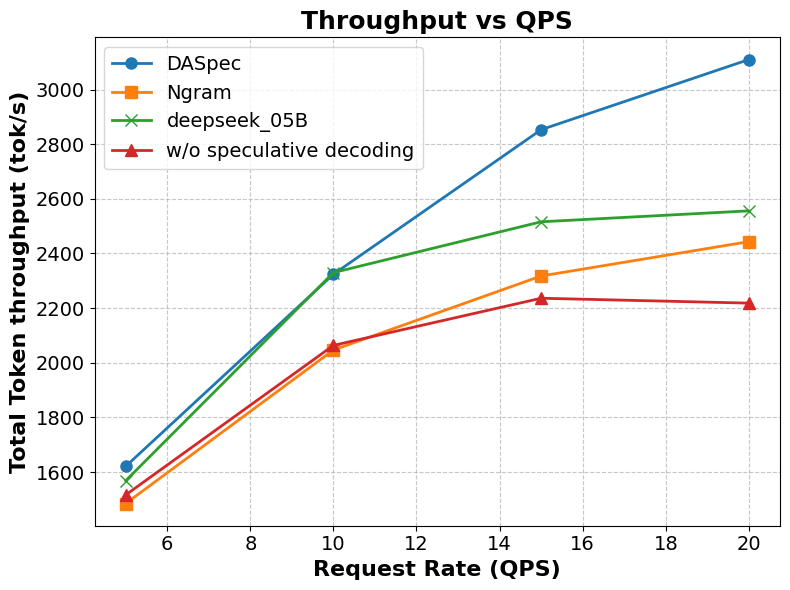

[1.1022727272727273, 1.148936170212766, 1.6666666666666667, 1.4666666666666666]
1.3461355577047067
[1.127906976744186, 1.3170731707317074, 1.5, 1.2941176470588236]
1.3097744486336793
[1.4264705882352942, 1.3846153846153846, 2.727272727272727, 2.2]
1.9345896750308513


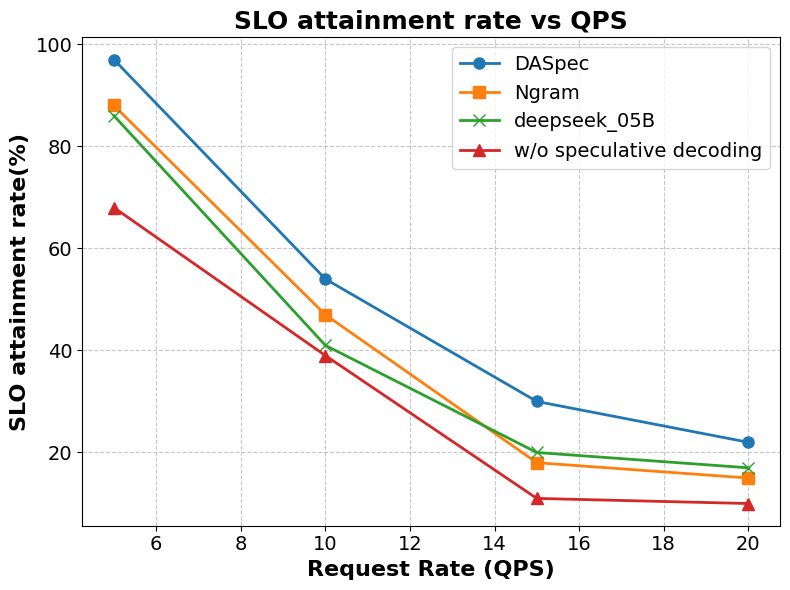

In [4]:
# 20 条请求 1 2 4 8 disable 设置32batch
deep05b_throughput=[281.11,388.90,509.31,569.17]
ngram_throughput=[266.15,377.80,429.99,503.26]
nomal_throughput=[259.53,353.32,428.58,478.60] 
ngram_tpot=[21.97,26.27,25.56,30.40]
deep_tpot=[25.52,24.66,25.80,32.90]
nomal_tpot=[23.77,23.78,22.92,26.01]
# 200 条请求 5 10 15 20
# disable_batch =32
# ngram_throughput=[1580,2359.41,2689.62,3079.57]
nomal_throughput= [1516.41,2063.70,2236.23,2218.37]
nomal_slo=[68,39,11,10]
# nomal_throughput=[1561,2361,2801,3056]
deep05_throughput=[1568.46,2330,2516,2556]
deep05_slo=[86,41,20,17] #[97,54,30,22]
ngram_throughput=[1485,2046.82 ,2317.65,2443.33]
# deep_nodisable_throughput=[1621,2289,2439,4383]
ngram_slo=[88,47,18,15]
my=[1659,2341,2853,3109.76]
# 第一个双向，后面 单向diasable43
my=[1621,2324,2853,3109.76]
my_slo=[97,54,30,22] 
# --speculative-disable-by-batch-size 32 33 34
datas = [my,ngram_throughput,deep05_throughput,nomal_throughput]
for i,data in enumerate(datas[1:]):
    print([my[i]/data[i] for i in range(len(my))])
names = ['DASpec','Ngram','deepseek_05B','w/o speculative decoding']
common_plt(plt,[5,10,15,20],datas,names)
datas = [my_slo,ngram_slo,deep05_slo,nomal_slo]
for i,data in enumerate(datas[1:]):
    print([my_slo[i]/data[i] for i in range(len(my_slo))])
    print(sum([my_slo[i]/data[i] for i in range(len(my_slo))])/len(my_slo))
names = ['DASpec','Ngram','deepseek_05B','w/o speculative decoding']
common_plt(plt,[5,10,15,20],datas,names,ylabel='SLO attainment rate(%)',title='SLO attainment rate vs QPS')

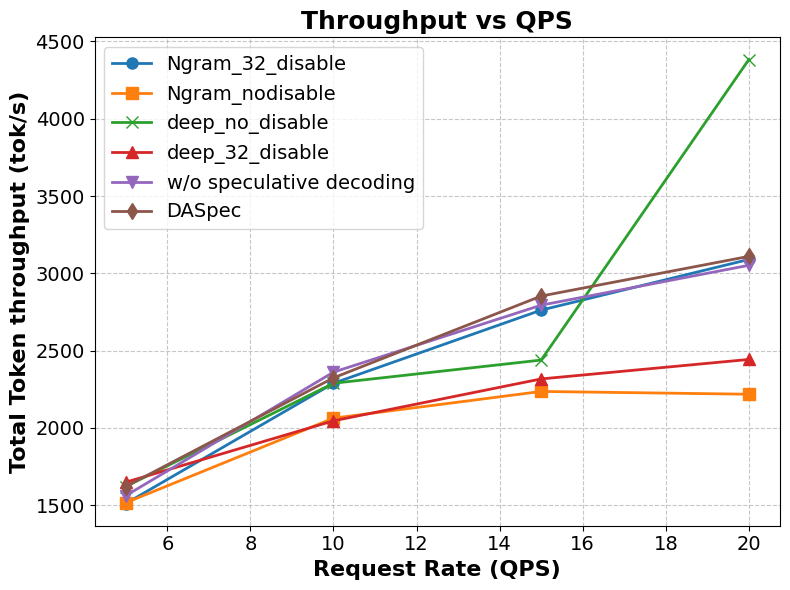

In [5]:
ngram_32_disable=[1511,2289,2762,3090]
ngram_nodisable=[1516,2063,2236,2218]
deep_no_disable=[1621,2289,2439,4383]
deep_32_disable=[1649,2046,2317,2443]
nomal=[1561.93,2361,2794,3052]
my=[1621,2324,2853,3109.76]
datas = [ngram_32_disable,ngram_nodisable,deep_no_disable,deep_32_disable,nomal,my]
names = ['Ngram_32_disable','Ngram_nodisable','deep_no_disable','deep_32_disable','w/o speculative decoding','DASpec']
common_plt(plt,[5,10,15,20],datas,names)

[1745.38, 2779.21, 3346.87, 3799.18]
[1749.7, 2571.08, 3032.54, 3304.9]
0.9975310053151969
1.0809504177232914
1.1036523838102712
1.1495597446216224


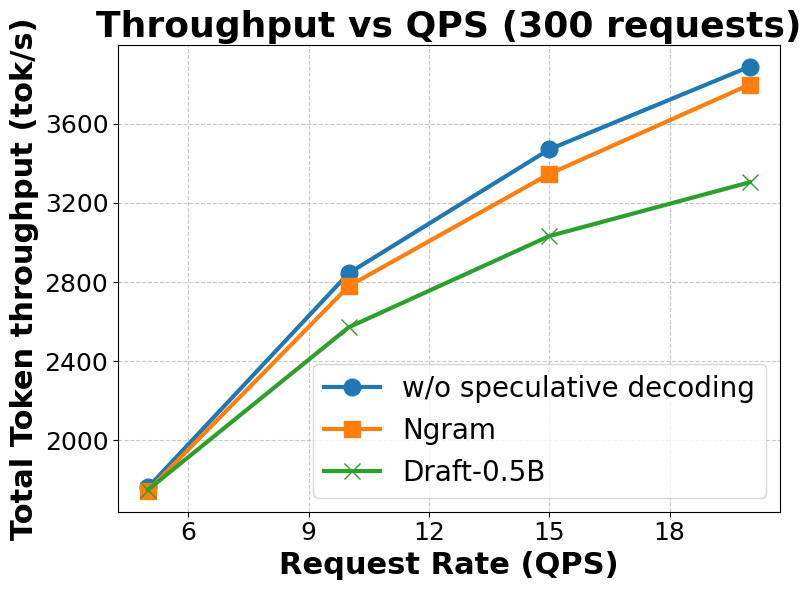

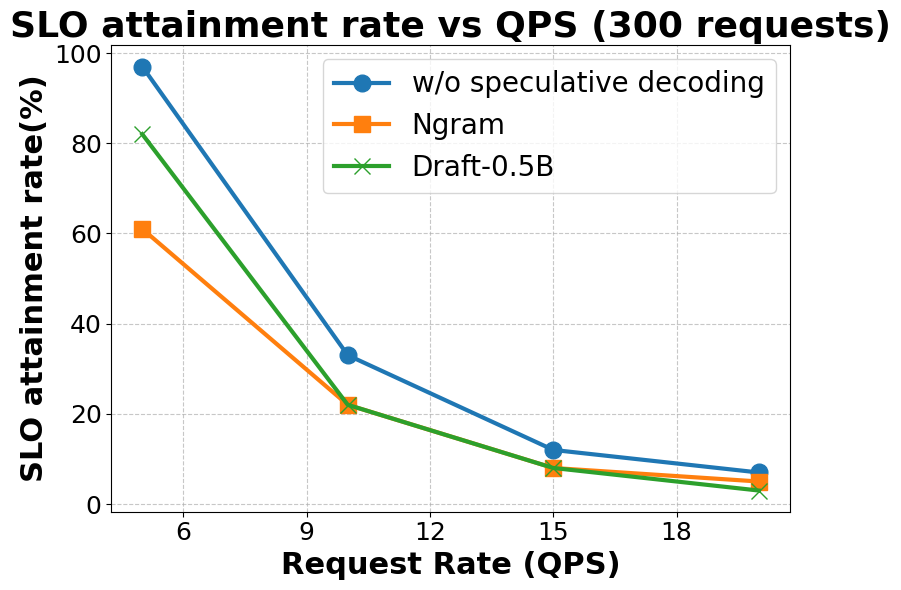

In [9]:
org=[1761.64,2844.59,3471.05,3890.10]
ngram=[1745.38,2779.21,3346.87,3799.18] #read_log('../logs3/deepseek_qps_ngram_300_new.log')[0]# disable 4 #[1745.38,2779.21,3346.87,3799.18] disable 32
print(ngram)
deep_05b=[1749.70,2571.08,3032.54,3304.90] #read_log('../logs3/deepseek_qps_deep_300_new.log')[0]#[1749.70,2571.08,3032.54,3304.90] disable 32
print(deep_05b)
for i, data in enumerate(ngram):
    print(data/deep_05b[i])
ngram_slo=[61,22,8,5]
org_slo=[97,33,12,7]
deep_05b_slo=[82,22,8,3]
datas = [org,ngram,deep_05b]
names = ['w/o speculative decoding','Ngram','Draft-0.5B']
common_plt(plt,[5,10,15,20],datas,names,title="Throughput vs QPS (300 requests)",save_path='./figs/throughput_qps_300.pdf')
datas = [org_slo,ngram_slo,deep_05b_slo]
names = ['w/o speculative decoding','Ngram','Draft-0.5B']
common_plt(plt,[5,10,15,20],datas,names,ylabel='SLO attainment rate(%)',title="SLO attainment rate vs QPS (300 requests)")

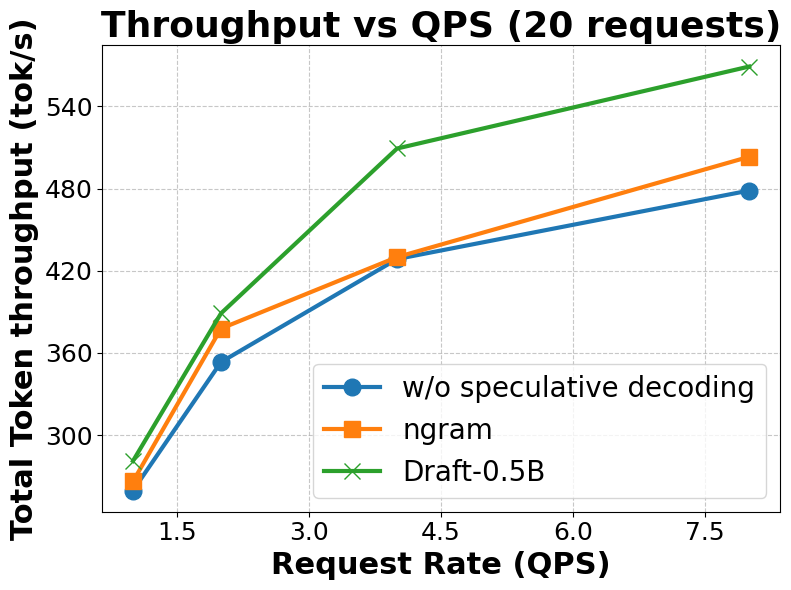

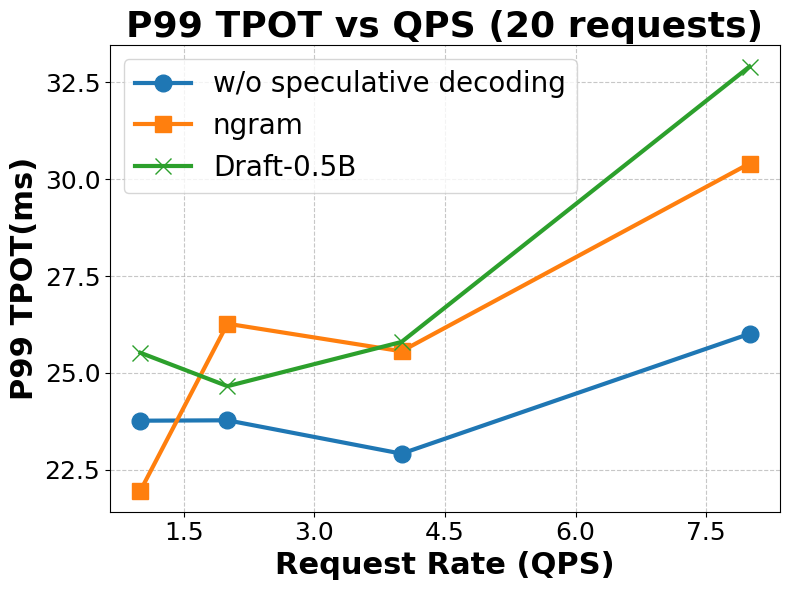

In [3]:
deep05b_throughput=[281.11,388.90,509.31,569.17]
ngram_throughput=[266.15,377.80,429.99,503.26]
nomal_throughput=[259.53,353.32,428.58,478.60] 
ngram_tpot=[21.97,26.27,25.56,30.40]
deep_tpot=[25.52,24.66,25.80,32.90]
nomal_tpot=[23.77,23.78,22.92,26.01]
datas = [nomal_throughput,ngram_throughput,deep05b_throughput]
names = ['w/o speculative decoding','ngram','Draft-0.5B']
common_plt(plt,[1,2,4,8],datas,names,title="Throughput vs QPS (20 requests)",save_path='./figs/throughput_qps_20.pdf')

datas = [nomal_tpot,ngram_tpot,deep_tpot]
names = ['w/o speculative decoding','ngram','Draft-0.5B']
common_plt(plt,[1,2,4,8],datas,names,ylabel='P99 TPOT(ms)',title="P99 TPOT vs QPS (20 requests)")

In [ ]:
# 10 个请求 
qps=[0.1,0.3,0.6,1] # 0.1 看不出差距，从0.6开始有差距
org_medium_e2e=[2864.90,2922.48,2966.53,3016.59]
org_throughput=[26.65,79.95,154.53,245.42]
deep_medium_e2e=[2222.05,2342.21,2526.13,2419.26]
deep_throughput=[26.64,79.93,156.07,251.95]
ngram_medium_e2e=[2219.63,2264.50,2337.76,2644.92]
ngram_throughput=[26.65,79.93,155.58,248.38]
datas = [org_throughput,ngram_throughput,deep_throughput]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,title="Throughput vs QPS (20 requests)")

datas = [org_medium_e2e,ngram_medium_e2e,deep_medium_e2e]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS (20 requests)")

In [1]:


qps=[1,2,4,8]
org_throughput,org_e2e = read_log('../logs3/deepseek_qps_org_10_new.log')
ngram_throughput,ngram_e2e = read_log('../logs3/deepseek_qps_ngram_10_new.log')
deep_throughput,deep_e2e = read_log('../logs3/deepseek_qps_deep_10_new.log')
print(org_throughput,deep_throughput)
datas = [org_throughput,ngram_throughput,deep_throughput]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,title="Throughput vs QPS (20 requests)")
datas = [org_e2e,ngram_e2e,deep_e2e]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS (20 requests)")

NameError: name 'read_log' is not defined

In [14]:
import json

with open("../action_time_history.json", "r") as f:
    action_time_history = json.load(f)


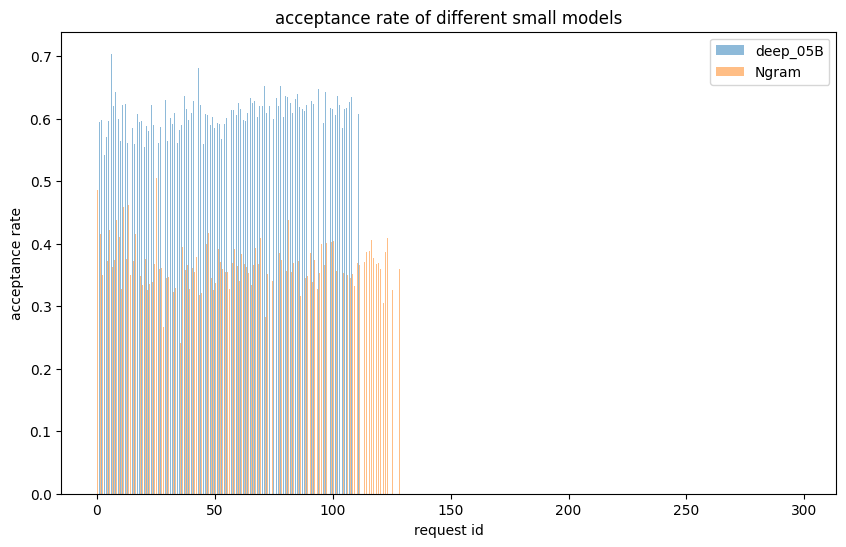

In [22]:
acceptance_rate_1    = []
acceptance_rate_2 = []
for i in range(1,300):
    acceptance_rate_1.append(action_time_history['0'][f'{i}']['acceptance_rate'])
    acceptance_rate_2.append(action_time_history['1'][f'{i}']['acceptance_rate'])
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(range(len(acceptance_rate_1)), acceptance_rate_1, alpha=0.5, label='deep_05B', width=0.4)
plt.bar([x + 0.4 for x in range(len(acceptance_rate_2))], acceptance_rate_2, alpha=0.5, label='Ngram', width=0.4)

plt.xlabel('request id')
plt.ylabel('acceptance rate') 
plt.title('acceptance rate of different small models')
plt.legend()
plt.show()


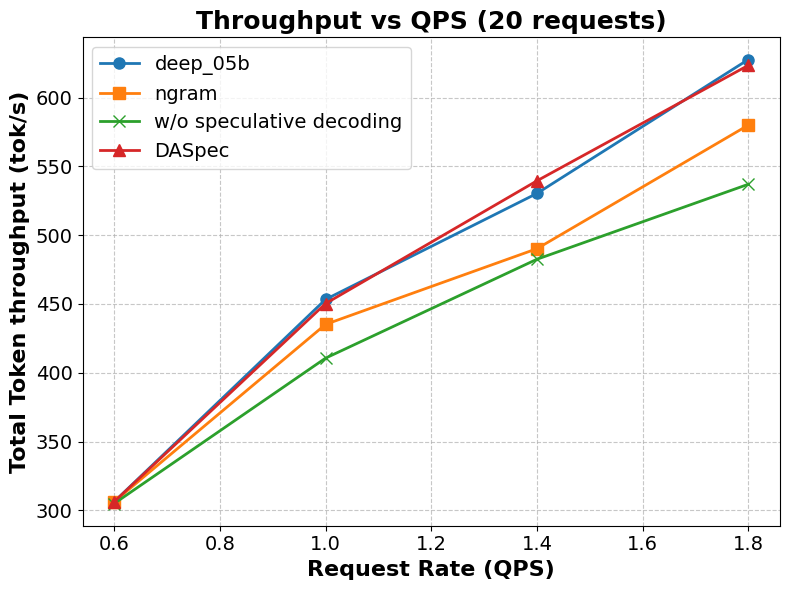

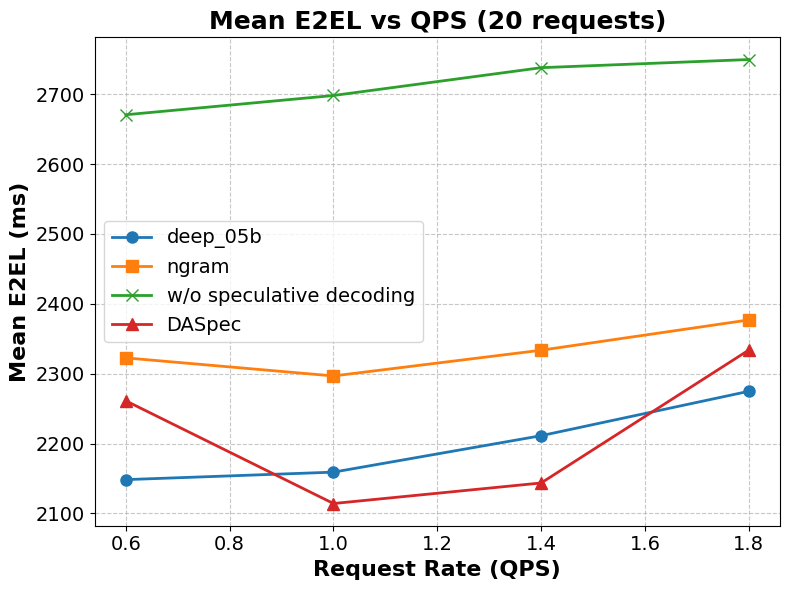

In [ ]:
qps=[0.6,1,1.4,1.8]
rate_06_throughput,rate_06_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_0.6.json')
rate_1_throughput,ratqps=[0.6,1,1.4,1.8]
rate_06_throughput,rate_06_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_0.6.json')
rate_1_throughput,rate_1_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_1.0.json')
rate_14_throughput,rate_14_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_1.4.json')
rate_18_throughput,rate_18_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_1.8.json')
deep_05b_throughput=[rate_06_throughput[0],rate_1_throughput[0],rate_14_throughput[0],rate_18_throughput[0]]
ngram_throughput=[rate_06_throughput[1],rate_1_throughput[1],rate_14_throughput[1],rate_18_throughput[1]]
no_spec_throughput=[rate_06_throughput[2],rate_1_throughput[2],rate_14_throughput[2],rate_18_throughput[2]]
DASpec_throughput=[rate_06_throughput[3],rate_1_throughput[3],rate_14_throughput[3],rate_18_throughput[3]]
datas = [deep_05b_throughput,ngram_throughput,no_spec_throughput,DASpec_throughput]
names = ['deep_05b','ngram','w/o speculative decoding','DASpec']
common_plt(plt,qps,datas,names,title="Throughput vs QPS (20 requests)")

deep_05b_e2e=[rate_06_e2e[0],rate_1_e2e[0],rate_14_e2e[0],rate_18_e2e[0]]
ngram_e2e=[rate_06_e2e[1],rate_1_e2e[1],rate_14_e2e[1],rate_18_e2e[1]]
no_spec_e2e=[rate_06_e2e[2],rate_1_e2e[2],rate_14_e2e[2],rate_18_e2e[2]]
DASpec_e2e=[rate_06_e2e[3],rate_1_e2e[3],rate_14_e2e[3],rate_18_e2e[3]]
datas = [deep_05b_e2e,ngram_e2e,no_spec_e2e,DASpec_e2e]
names = ['deep_05b','ngram','w/o speculative decoding','DASpec']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS (20 requests)")


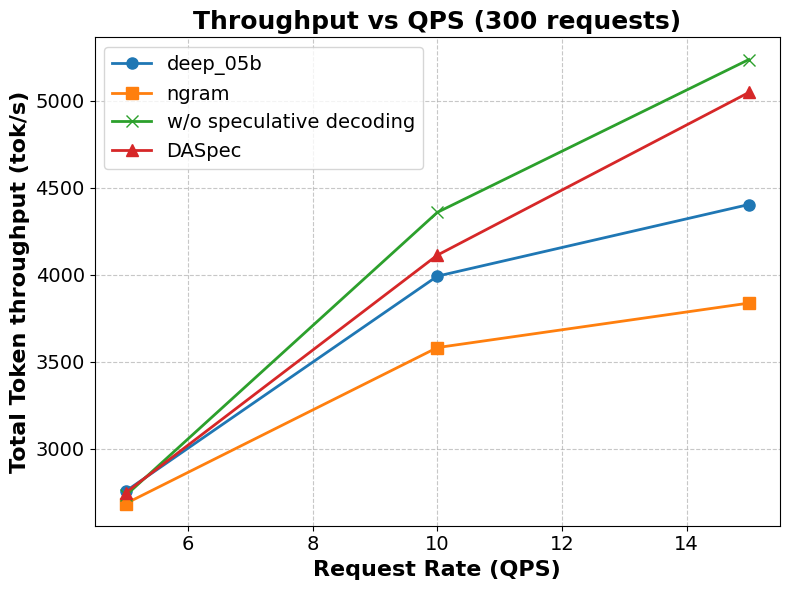

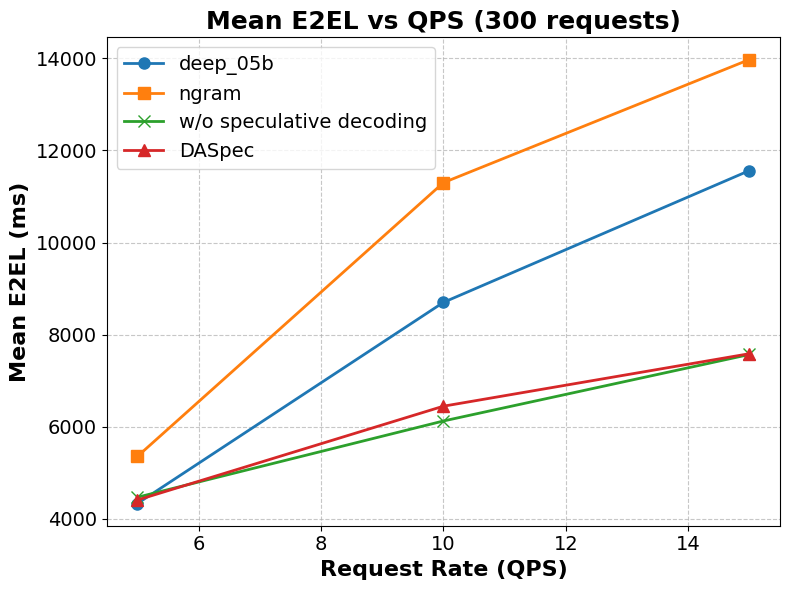

In [9]:
qps=[5,10,15]
rate_06_throughput,rate_06_e2e =read_log('../benchmark_results/benchmark_rate_ilp_300_5.0.json')
rate_1_throughput,rate_1_e2e =read_log('../benchmark_results/benchmark_rate_ilp_300_10.0.json')
rate_14_throughput,rate_14_e2e =read_log('../benchmark_results/benchmark_rate_ilp_300_15.0.json')

deep_05b_throughput=[rate_06_throughput[0],rate_1_throughput[0],rate_14_throughput[0]]
ngram_throughput=[rate_06_throughput[1],rate_1_throughput[1],rate_14_throughput[1]]
no_spec_throughput=[rate_06_throughput[2],rate_1_throughput[2],rate_14_throughput[2]]
DASpec_throughput=[rate_06_throughput[3],rate_1_throughput[3],rate_14_throughput[3]]
datas = [deep_05b_throughput,ngram_throughput,no_spec_throughput,DASpec_throughput]
names = ['deep_05b','ngram','w/o speculative decoding','DASpec']
common_plt(plt,qps,datas,names,title="Throughput vs QPS (300 requests)")

deep_05b_e2e=[rate_06_e2e[0],rate_1_e2e[0],rate_14_e2e[0]]
ngram_e2e=[rate_06_e2e[1],rate_1_e2e[1],rate_14_e2e[1]]
no_spec_e2e=[rate_06_e2e[2],rate_1_e2e[2],rate_14_e2e[2]]
DASpec_e2e=[rate_06_e2e[3],rate_1_e2e[3],rate_14_e2e[3]]
datas = [deep_05b_e2e,ngram_e2e,no_spec_e2e,DASpec_e2e]
names = ['deep_05b','ngram','w/o speculative decoding','DASpec']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS (300 requests)")


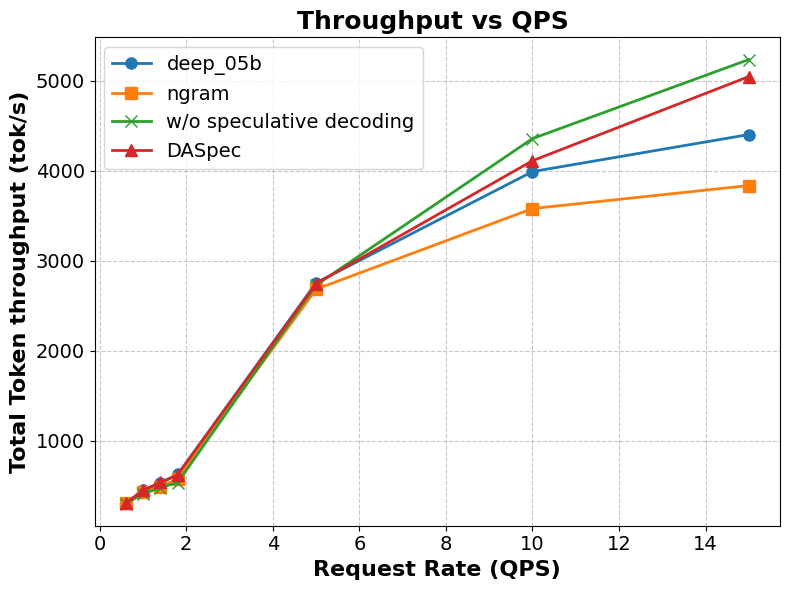

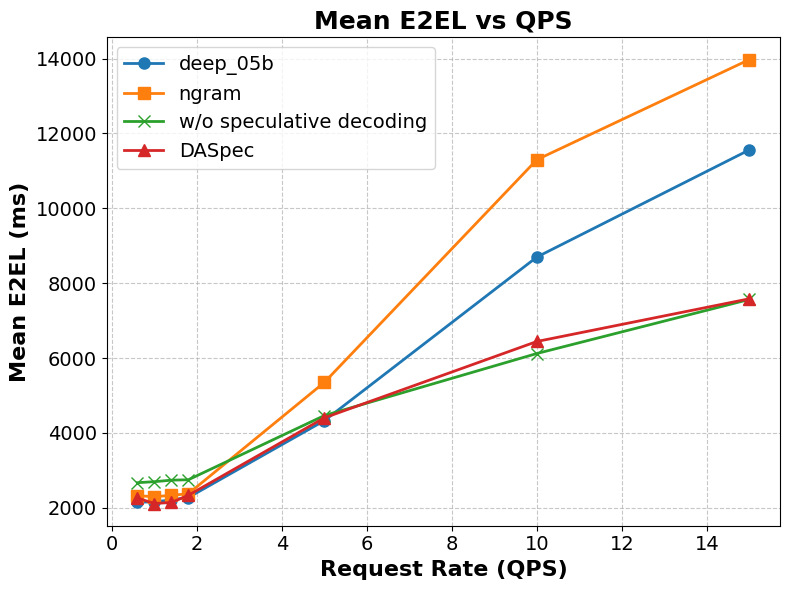

In [10]:
qps=[0.6,1,1.4,1.8,5,10,15]
rate_06_throughput,rate_06_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_0.6.json')
rate_1_throughput,rate_1_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_1.0.json')
rate_14_throughput,rate_14_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_1.4.json')
rate_18_throughput,rate_18_e2e =read_log('../benchmark_results/benchmark_rate_ilp_20_1.8.json')
rate_5_throughput,rate_5_e2e =read_log('../benchmark_results/benchmark_rate_ilp_300_5.0.json')
rate_10_throughput,rate_10_e2e =read_log('../benchmark_results/benchmark_rate_ilp_300_10.0.json')
rate_15_throughput,rate_15_e2e =read_log('../benchmark_results/benchmark_rate_ilp_300_15.0.json')

deep_05b_throughput=[rate_06_throughput[0],rate_1_throughput[0],rate_14_throughput[0],rate_18_throughput[0],rate_5_throughput[0],rate_10_throughput[0],rate_15_throughput[0]]
ngram_throughput=[rate_06_throughput[1],rate_1_throughput[1],rate_14_throughput[1],rate_18_throughput[1],rate_5_throughput[1],rate_10_throughput[1],rate_15_throughput[1]]
no_spec_throughput=[rate_06_throughput[2],rate_1_throughput[2],rate_14_throughput[2],rate_18_throughput[2],rate_5_throughput[2],rate_10_throughput[2],rate_15_throughput[2]]
DASpec_throughput=[rate_06_throughput[3],rate_1_throughput[3],rate_14_throughput[3],rate_18_throughput[3],rate_5_throughput[3],rate_10_throughput[3],rate_15_throughput[3]]
datas = [deep_05b_throughput,ngram_throughput,no_spec_throughput,DASpec_throughput]
names = ['deep_05b','ngram','w/o speculative decoding','DASpec']
common_plt(plt,qps,datas,names,title="Throughput vs QPS ")

deep_05b_e2e=[rate_06_e2e[0],rate_1_e2e[0],rate_14_e2e[0],rate_18_e2e[0],rate_5_e2e[0],rate_10_e2e[0],rate_15_e2e[0]]
ngram_e2e=[rate_06_e2e[1],rate_1_e2e[1],rate_14_e2e[1],rate_18_e2e[1],rate_5_e2e[1],rate_10_e2e[1],rate_15_e2e[1]]
no_spec_e2e=[rate_06_e2e[2],rate_1_e2e[2],rate_14_e2e[2],rate_18_e2e[2],rate_5_e2e[2],rate_10_e2e[2],rate_15_e2e[2]]
DASpec_e2e=[rate_06_e2e[3],rate_1_e2e[3],rate_14_e2e[3],rate_18_e2e[3],rate_5_e2e[3],rate_10_e2e[3],rate_15_e2e[3]]
datas = [deep_05b_e2e,ngram_e2e,no_spec_e2e,DASpec_e2e]
names = ['deep_05b','ngram','w/o speculative decoding','DASpec']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS")


In [5]:
import torch

a = torch.randn(2, 3) 
print(a.untyped_storage().data_ptr()) 
b = torch.randn(2, 3)
print(b.untyped_storage().data_ptr())
a = torch.cat([a, b], dim=0)  
print(a.untyped_storage().data_ptr())

748866624
756665472
666020672


In [ ]:

# 训练验证模型
from sklearn.linear_model import LinearRegression
import numpy as np

# 计算x1和x2与y的相关系数
from scipy import stats

# 训练验证模型
from sklearn.linear_model import LinearRegression
import numpy as np
from joblib import dump
def read_json(file_path):
    import json
    with open(file_path, "r") as f:
        action_time_history = json.load(f)
        # 将字符串key转换为int
        converted_history = {}
        for action_str in   action_time_history:
            action_int = int(action_str)
            converted_history[action_int] = {}
            for batch_str in action_time_history[action_str]:
                batch_int = int(batch_str)
                converted_history[action_int][batch_int] = action_time_history[action_str][batch_str]
                for i in range(2):
                    # 这样就会多出两个，一共四个，前两个是str 后两个是int
                    converted_history[action_int][batch_int][int(i)] = action_time_history[action_str][batch_str][str(i)]
        action_time_history = converted_history
    return action_time_history


action_time_history = {}
train_data_v = []
train_data_d = []
for i in range(1,6):
    gamma = i
    nospec_action_time_history = read_json(f"../nospec_300_new{i}.json")
    deep_action_time_history = read_json(f"../deep_05b_300_new{i}.json")
    action_time_history[2] = nospec_action_time_history[2]
    action_time_history[0] = deep_action_time_history[0]
    
    for batch in range(1,300):
        data = action_time_history[2][batch][1]
        for i in range(len(data['scoring_time'])):
            y = data['scoring_time'][i]
            x1 = data['context_length'][i]
            x2 = batch 
            train_data_v.append((x1,x2,y))



action_time_history={}
for i in range(1,6):    
    gamma = i
    nospec_action_time_history = read_json(f"../nospec_300_new{i}.json")
    deep_action_time_history = read_json(f"../deep_05b_300_new{i}.json")
    action_time_history[2] = nospec_action_time_history[2]
    action_time_history[0] = deep_action_time_history[0]
    for batch in range(1,300):
        datas = action_time_history[0][batch][1]# 0 是指action0 1是decode stage
        for i in range(len(datas['proposal_time'])):
            y = datas['proposal_time'][i] / gamma 
            x1 = datas['context_length'][i]
            x2 = batch
            train_data_d.append((x1,x2,y))

def train_and_evaluate_model(train_data, model_save_path=None, test_size=100, random_state=42, n_estimators=100):
    """
    训练并评估随机森林和线性回归模型
    
    参数:
        train_data: 包含(x1, x2, y)元组的列表，其中x1为context_length，x2为batch_size，y为目标变量
        model_save_path: 模型保存路径，如果为None则不保存
        test_size: 测试集大小
        random_state: 随机种子
        n_estimators: 随机森林中的树数量
        
    返回:
        dict: 包含训练好的模型和评估指标的字典
    """
    import numpy as np
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score
    from sklearn.model_selection import train_test_split
    from scipy import stats
    import time
    from joblib import dump
    
    # 转换为numpy数组
    train_data_array = np.array(train_data)
    
    # 提取特征和目标变量
    x1_values = [x1 for x1, _, _ in train_data]
    x2_values = [x2 for _, x2, _ in train_data]
    y_values = [y for _, _, y in train_data]
    
    # 划分训练集和测试集
    train_idx, test_idx = train_test_split(np.arange(len(train_data)), test_size=test_size, random_state=random_state)
    
    # 构建训练集和测试集
    X_train = np.array([[x1, x2] for x1, x2, _ in train_data_array[train_idx]])
    y_train = np.array([y for _, _, y in train_data_array[train_idx]])
    X_test = np.array([[x1, x2] for x1, x2, _ in train_data_array[test_idx]])
    y_test = np.array([y for _, _, y in train_data_array[test_idx]])
    
    # 训练随机森林模型
    rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
    rf_model.fit(X_train, y_train)
    
    # 评估随机森林模型在训练集上的表现
    y_train_pred = rf_model.predict(X_train)
    rf_train_r2 = r2_score(y_train, y_train_pred)
    
    # 评估随机森林模型在测试集上的表现
    begin_time = time.time()
    y_test_pred = rf_model.predict(X_test)
    rf_test_r2 = r2_score(y_test, y_test_pred)
    rf_inference_time = time.time() - begin_time
    
    # 获取特征重要性
    feature_importance = rf_model.feature_importances_
    
    # 计算相关系数
    corr_x1_y = stats.pearsonr(x1_values, y_values)
    corr_x2_y = stats.pearsonr(x2_values, y_values)
    
    # 训练线性回归模型
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    # 评估线性回归模型
    lr_train_r2 = lr_model.score(X_train, y_train)
    begin_time = time.time()
    lr_test_r2 = lr_model.score(X_test, y_test)
    lr_inference_time = time.time() - begin_time
    
    # 保存模型
    if model_save_path:
        dump(rf_model, f"{model_save_path}_RF.pkl")
        dump(lr_model, f"{model_save_path}_LR.pkl")
    
    # 输出评估结果
    print("\n随机森林模型评估结果:")
    print(f"训练集 R2 分数: {rf_train_r2:.4f}")
    print(f"测试集 R2 分数: {rf_test_r2:.4f}")
    print(f"推理时间: {rf_inference_time:.6f} 秒")
    
    print("\n特征重要性:")
    print(f"context_length重要性: {feature_importance[0]:.4f}")
    print(f"batch_size重要性: {feature_importance[1]:.4f}")
    
    print(f"\n相关系数分析 (样本数量: {len(train_data)}):")
    print(f"x1(context_length)与y的相关系数: {corr_x1_y[0]:.4f}, p值: {corr_x1_y[1]:.4f}")
    print(f"x2(batch_size)与y的相关系数: {corr_x2_y[0]:.4f}, p值: {corr_x2_y[1]:.4f}")
    
    print("\n线性回归模型评估结果:")
    print(f"系数: {lr_model.coef_}")
    print(f"截距: {lr_model.intercept_}")
    print(f"训练集 R2 分数: {lr_train_r2:.4f}")
    print(f"测试集 R2 分数: {lr_test_r2:.4f}")
    print(f"推理时间: {lr_inference_time:.6f} 秒")
    
    # 返回结果
    return {
        "rf_model": rf_model,
        "lr_model": lr_model,
        "rf_train_r2": rf_train_r2,
        "rf_test_r2": rf_test_r2,
        "lr_train_r2": lr_train_r2,
        "lr_test_r2": lr_test_r2,
        "feature_importance": feature_importance,
        "corr_x1_y": corr_x1_y,
        "corr_x2_y": corr_x2_y
    }

# 训练验证模型
results_v = train_and_evaluate_model(train_data_v, model_save_path="../DeepSeek-R1-Qwen2.5-0.5B-Verify")
print("=====================")
# 训练草稿模型
results_d = train_and_evaluate_model(train_data_d, model_save_path="../DeepSeek-R1-DRAFT-Qwen2.5-0.5B")


: 

In [ ]:
# 训练验证模型
from sklearn.linear_model import LinearRegression
import numpy as np

# 计算x1和x2与y的相关系数
from scipy import stats

# 训练验证模型
from sklearn.linear_model import LinearRegression
import numpy as np
from joblib import dump
def read_json(file_path):
    import json
    with open(file_path, "r") as f:
        action_time_history = json.load(f)
        # 将字符串key转换为int
        converted_history = {}
        for action_str in   action_time_history:
            action_int = int(action_str)
            converted_history[action_int] = {}
            for batch_str in action_time_history[action_str]:
                batch_int = int(batch_str)
                converted_history[action_int][batch_int] = action_time_history[action_str][batch_str]
                for i in range(2):
                    # 这样就会多出两个，一共四个，前两个是str 后两个是int
                    converted_history[action_int][batch_int][int(i)] = action_time_history[action_str][batch_str][str(i)]
        action_time_history = converted_history
    return action_time_history

action_time_history = {}
train_data_v = []
train_data_d = []
acc_datas = []
for i in range(4,5):
    gamma = i
    nospec_action_time_history = read_json(f"../nospec_300_new{i}.json")
    deep_action_time_history = read_json(f"../deep_05b_300_new{i}.json")
    action_time_history[2] = nospec_action_time_history[2]
    action_time_history[0] = deep_action_time_history[0]
    for batch in range(1,2):
        datas = action_time_history[0][batch][1]# 0 是指action0 1是decode stage
        acc_datas  = datas["accepted_tokens_length"]
import numpy as np
import matplotlib.pyplot as plt

def sliding_window_prediction(data, window_size=5):
    """
    使用滑动窗口平均值预测下一个值并计算与真实值的差距
    
    参数:
    data - 数据数组
    window_size - 滑动窗口大小
    """
    predictions = []
    actual_values = []
    errors = []
    
    # 从window_size开始，因为需要前window_size个数据来预测
    for i in range(window_size, len(data)):
        # 获取当前窗口
        window = data[i-window_size:i]
        # 使用窗口平均值作为预测
        prediction = sum(window) / window_size
        
        # 实际值
        actual = data[i]
        
        predictions.append(prediction)
        actual_values.append(actual)
        errors.append(prediction - actual)
    
    # 计算平均绝对误差
    mae = sum(abs(e) for e in errors) / len(errors)
    # 计算均方根误差
    rmse = np.sqrt(sum(e**2 for e in errors) / len(errors))
    
    print(f"\nsliding_window_prediction 平均绝对误差 (MAE): {mae:.2f}")
    print(f"sliding_window_prediction 均方根误差 (RMSE): {rmse:.2f}")
    
    return predictions, actual_values, errors

def exponential_smoothing(data, alpha=0.3):
    """
    使用指数平滑法预测下一个值
    
    参数:
    data - 数据数组
    alpha - 平滑系数(0-1之间)，越大表示对新数据越敏感
    """
    predictions = []
    actual_values = []
    errors = []
    
    # 第一个预测值就是第一个观测值
    smoothed = data[0]
    
    for i in range(1, len(data)):
        # 记录上一个平滑值作为预测值
        prediction = smoothed
        # 获取实际值
        actual = data[i]
        # 更新平滑值: 新平滑值 = α×观测值 + (1-α)×上一个平滑值
        smoothed = alpha * actual + (1 - alpha) * smoothed
        
        predictions.append(prediction)
        actual_values.append(actual)
        errors.append(prediction - actual)
    
    # 计算平均绝对误差
    mae = sum(abs(e) for e in errors) / len(errors)
    # 计算均方根误差
    rmse = np.sqrt(sum(e**2 for e in errors) / len(errors))
    
    print(f"\n exponential_smoothing 平均绝对误差 (MAE): {mae:.2f}")
    print(f"exponential_smoothing 均方根误差 (RMSE): {rmse:.2f}")
    
    return predictions, actual_values, errors



def weighted_moving_average(data, window_size=5, weights=None):
    """
    使用加权移动平均预测下一个值
    
    参数:
    data - 数据数组
    window_size - 窗口大小
    weights - 权重数组，默认为线性增加的权重
    """
    if weights is None:
        # 默认权重，线性递增
        weights = list(range(1, window_size + 1))
        # 归一化权重使其和为1
        weights = [w / sum(weights) for w in weights]
    
    predictions = []
    actual_values = []
    errors = []
    
    for i in range(window_size, len(data)):
        window = data[i-window_size:i]
        # 计算加权平均
        prediction = sum(w * x for w, x in zip(weights, window))
        
        actual = data[i]
        
        predictions.append(prediction)
        actual_values.append(actual)
        errors.append(prediction - actual)
    
    # 计算误差
    mae = sum(abs(e) for e in errors) / len(errors)
    rmse = np.sqrt(sum(e**2 for e in errors) / len(errors))
    
    print(f"\n weighted_moving_average 平均绝对误差 (MAE): {mae:.2f}")
    print(f" weighted_moving_average 均方根误差 (RMSE): {rmse:.2f}")
    
    return predictions, actual_values, errors

def naive_and_drift_methods(data, window_size=5):
    """
    实现两种方法：
    1. 朴素法 - 使用最后一个值作为预测
    2. 漂移法 - 考虑趋势的简单预测
    
    参数:
    data - 数据数组
    window_size - 计算漂移法趋势的窗口大小
    """
    naive_predictions = []
    drift_predictions = []
    actual_values = []
    naive_errors = []
    drift_errors = []
    
    for i in range(window_size, len(data)):
        # 朴素法 - 使用前一个值预测
        naive_pred = data[i-1]
        
        # 漂移法 - 根据过去的趋势预测
        # 计算平均变化率
        change_rate = (data[i-1] - data[i-window_size]) / (window_size - 1)
        drift_pred = data[i-1] + change_rate
        
        actual = data[i]
        
        naive_predictions.append(naive_pred)
        drift_predictions.append(drift_pred)
        actual_values.append(actual)
        naive_errors.append(naive_pred - actual)
        drift_errors.append(drift_pred - actual)
    
    # 计算朴素法误差
    naive_mae = sum(abs(e) for e in naive_errors) / len(naive_errors)
    naive_rmse = np.sqrt(sum(e**2 for e in naive_errors) / len(naive_errors))
    
    # 计算漂移法误差
    drift_mae = sum(abs(e) for e in drift_errors) / len(drift_errors)
    drift_rmse = np.sqrt(sum(e**2 for e in drift_errors) / len(drift_errors))
    
    print(f"\n朴素法平均绝对误差 (MAE): {naive_mae:.2f}")
    print(f"朴素法均方根误差 (RMSE): {naive_rmse:.2f}")
    print(f"\n漂移法平均绝对误差 (MAE): {drift_mae:.2f}")
    print(f"漂移法均方根误差 (RMSE): {drift_rmse:.2f}")
    
    return naive_predictions, drift_predictions, actual_values
# 使用给定的acc_datas数据
# 因为您没有提供实际的acc_datas值，我假设您已经有了这个数组
# 如果acc_datas数据量不足，请确保它至少有6个元素以上
if len(acc_datas) > 5:
    
    # predictions, actual_values, errors = sliding_window_prediction(acc_datas)
    # naive_and_drift_methods(acc_datas)
    # weighted_moving_average(acc_datas)
    sliding_window_prediction(acc_datas)
    for ratio in np.arange(0.1, 1.1, 0.1):
        print(f"Ratio: {ratio:.1f}")
        exponential_smoothing(acc_datas,ratio)
        #print(i,predictions, actual_values, errors)
    
#     # 可视化结果
#     plt.figure(figsize=(12, 6))
    
#     # 绘制原始数据和预测值
#     plt.subplot(2, 1, 1)
#     plt.plot(range(5, len(acc_datas)), actual_values, 'b-', label='actual')
#     plt.plot(range(5, len(acc_datas)), predictions, 'r--', label='pred')
#     plt.legend()
#     plt.title('sliding window prediction')
    
#     # 绘制误差
#     plt.subplot(2, 1, 2)
#     plt.bar(range(5, len(acc_datas)), errors)
#     plt.axhline(y=0, color='r', linestyle='-')
#     plt.title('sliding window prediction error')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("数据量不足，无法进行滑动窗口预测。需要至少6个数据点。")


sliding_window_prediction 平均绝对误差 (MAE): 0.93
sliding_window_prediction 均方根误差 (RMSE): 1.18
Ratio: 0.1

 exponential_smoothing 平均绝对误差 (MAE): 0.91
exponential_smoothing 均方根误差 (RMSE): 1.12
Ratio: 0.2

 exponential_smoothing 平均绝对误差 (MAE): 0.89
exponential_smoothing 均方根误差 (RMSE): 1.11
Ratio: 0.3

 exponential_smoothing 平均绝对误差 (MAE): 0.88
exponential_smoothing 均方根误差 (RMSE): 1.12
Ratio: 0.4

 exponential_smoothing 平均绝对误差 (MAE): 0.89
exponential_smoothing 均方根误差 (RMSE): 1.13
Ratio: 0.5

 exponential_smoothing 平均绝对误差 (MAE): 0.90
exponential_smoothing 均方根误差 (RMSE): 1.15
Ratio: 0.6

 exponential_smoothing 平均绝对误差 (MAE): 0.91
exponential_smoothing 均方根误差 (RMSE): 1.17
Ratio: 0.7

 exponential_smoothing 平均绝对误差 (MAE): 0.93
exponential_smoothing 均方根误差 (RMSE): 1.19
Ratio: 0.8

 exponential_smoothing 平均绝对误差 (MAE): 0.95
exponential_smoothing 均方根误差 (RMSE): 1.22
Ratio: 0.9

 exponential_smoothing 平均绝对误差 (MAE): 0.97
exponential_smoothing 均方根误差 (RMSE): 1.26
Ratio: 1.0

 exponential_smoothing 平均绝对误差 (MAE): 0.99


In [ ]:
def f(x,ratio):
    return (1-0.6**(x+1))/ (0.4 *  (ratio+x *0.26))
ratio1 = []
ratio2 = []
ans = []
batch_size = range(1,30)
batchs = []
same_context_length = []
b  = []
for batch in batch_size:
    for i in range(len(action_time_history[0][batch][1]['proposal_time'])): # Td
        for j in range(len(action_time_history[2][batch][1]['scoring_time'])): # Tv
            #if action_time_history[0][batch][1]['context_length'][i] == action_time_history[2][batch][1]['context_length'][j]:
            per_token_time = action_time_history[0][batch][1]['proposal_time'][i]/4
            same_context_length.append((per_token_time/action_time_history[2][batch][1]['scoring_time'][j],batch))
for batch in batch_size:
    for i in range(len(action_time_history[2][batch][1]['scoring_time'])):
        b.append((batch/action_time_history[2][batch][1]['scoring_time'][i],batch))


b.sort(key=lambda x: x[1])
# 按batch size分组计算平均值和标准差
batch_stats = {}
for score, batch in b:
    if batch not in batch_stats:
        batch_stats[batch] = []
    batch_stats[batch].append(score)

batch_means = []
batch_stds = []
batch_sizes = []

for batch in sorted(batch_stats.keys()):
    scores = batch_stats[batch]
    batch_means.append(np.mean(scores))
    batch_stds.append(np.std(scores))
    batch_sizes.append(batch)

# 绘制折线图
plt.figure(figsize=(10,6))
plt.errorbar(batch_sizes, batch_means, yerr=batch_stds, fmt='-o', capsize=5)
plt.xlabel('batch size')
plt.ylabel('batch size / scoring time')
plt.title('batch size / scoring time vs batch size')
plt.grid(True)


print(same_context_length)
# 按batch size分组计算平均值和标准差
same_context_stats = {}
for ratio, batch in same_context_length:
    if batch not in same_context_stats:
        same_context_stats[batch] = []
    same_context_stats[batch].append(ratio)

same_context_means = []
same_context_stds = []
same_context_sizes = []

for batch in sorted(same_context_stats.keys()):
    ratios = same_context_stats[batch]
    same_context_means.append(np.mean(ratios))
    same_context_stds.append(np.std(ratios))
    same_context_sizes.append(batch)

# 绘制折线图
plt.figure(figsize=(10,6))
plt.errorbar(same_context_sizes, same_context_means, yerr=same_context_stds, fmt='-o', capsize=5)
plt.xlabel('batch size')
plt.ylabel('proposal time / scoring time')
plt.title('Ratio of proposal time to scoring time vs batch size')
plt.grid(True)


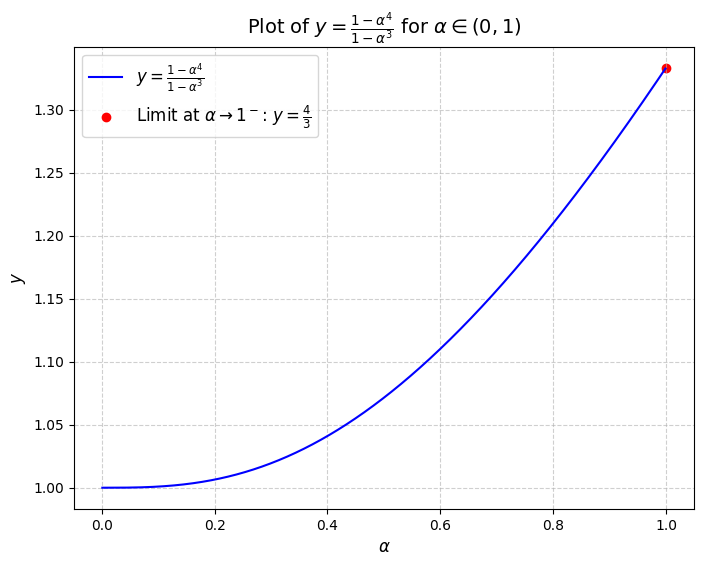

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 定义 alpha 的范围（0 到 1，不包括 0 和 1）
alpha = np.linspace(0.001, 0.999, 1000)

# 计算 y = (1 - alpha^4) / (1 - alpha^3)
y = (1 - alpha**4) / (1 - alpha**3)

# 绘制图像
plt.figure(figsize=(8, 6))
plt.plot(alpha, y, label=r'$y = \frac{1 - \alpha^4}{1 - \alpha^3}$', color='blue')
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'$y$', fontsize=12)
plt.title(r'Plot of $y = \frac{1 - \alpha^4}{1 - \alpha^3}$ for $\alpha \in (0, 1)$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# 处理 alpha=1 的极限情况（y = 4/3）
plt.scatter(1, 4/3, color='red', label=r'Limit at $\alpha \to 1^-$: $y = \frac{4}{3}$')
plt.legend(fontsize=12)

# 显示图像
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Plot deltas for total_latency
batch_sizes = range(1, 41)
min_b = 41
for action in [0, 1]:
    deltas = []
    for b in batch_sizes:
        if action_time_history1[action][b][1]["total_latency"] - 0 < 1e-6:
            min_b = min(min_b,b)
            break
batch_sizes = range(1, min_b)
for action in [0, 1]:
    deltas = []
    for b in batch_sizes:
        if b in action_time_history[action] and b in action_time_history1[action]:
            delta = abs(action_time_history1[action][b][1]["total_latency"] - 
                       action_time_history[action][b][1]["total_latency"])
            deltas.append(delta)
        else:
            deltas.append(0)
    print(action,deltas)
    ax1.plot(batch_sizes[:b], deltas, label=f'Action {action}')

ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Delta Decode Latency')
ax1.set_title('Decode Latency Delta')
ax1.legend()

# Plot deltas for prefill_time
for action in [0, 1, 2]:
    deltas = []
    for b in batch_sizes:
        if b in action_time_history[action] and b in action_time_history1[action]:
            delta = abs(action_time_history1[action][b][0]["prefill_time"] - 
                       action_time_history[action][b][0]["prefill_time"])
            deltas.append(delta)
        else:
            deltas.append(0)
    ax2.plot(batch_sizes, deltas, label=f'Action {action}')

ax2.set_xlabel('Batch Size') 
ax2.set_ylabel('Delta Prefill Time')
ax2.set_title('Prefill Time Delta')
ax2.legend()

plt.tight_layout()

# Calculate and print average deltas
avg_deltas = []
for action in [0, 1, 2]:
    total_delta = 0
    count = 0
    for b in batch_sizes:
        if b in action_time_history[action] and b in action_time_history1[action]:
            delta1 = abs(action_time_history1[action][b][1]["total_latency"] - 
                        action_time_history[action][b][1]["total_latency"])
            delta2 = abs(action_time_history1[action][b][0]["prefill_time"] - 
                        action_time_history[action][b][0]["prefill_time"])
            total_delta += (delta1 + delta2)
            count += 2
    avg_deltas.append(total_delta/count if count > 0 else 0)

avg_deltas


In [23]:
from pathlib import Path
import json
import re
table = {}
table2 = {}
action_map = {}

action_time_history = {}
train_data_v = []
train_data_d = []
acc_datas = []
def read_nospec_json_files(patternstr):
    """
    Read all JSON files in the parent directory that start with "nospec_300_new1".
    
    Returns:
        dict: Dictionary with filenames as keys and JSON content as values
    """
    json_files = []
    
    # Get the parent directory path
    #parent_directory = # Path(__file__).parent.parent
    # Change to profile_log directory
    profile_log_dir = '/home/hello/lirui/vllm_speculative/profile_log'
    if not Path(profile_log_dir).exists():
        print(f"Warning: {profile_log_dir} does not exist")
        return {}
    parent_directory = Path(profile_log_dir)
    # Define the regex pattern for files starting with "nospec_300_new1"
    pattern = re.compile(patternstr)
    
    # Get all JSON files in the directory
    for json_file in parent_directory.glob('*.json'):
        filename = json_file.name
        
        # Check if filename matches the pattern
        if pattern.match(filename):
            try:
                with open(json_file, 'r', encoding='utf-8') as f:
                    json_content = json.load(f)
                    json_files.append(json_content)
                    print(f"Successfully read: {filename}")
            except Exception as e:
                print(f"Error reading {filename}: {str(e)}")
    
    return json_files
def read_json(patternstr):
    import json
    results = read_nospec_json_files(patternstr)
    action_time_historys = []
    for action_time_history in results:
        # 将字符串key转换为int
        converted_history = {}
        for action_str in   action_time_history:
            action_int = int(action_str)
            converted_history[action_int] = {}
            for batch_str in action_time_history[action_str]:
                batch_int = int(batch_str)
                converted_history[action_int][batch_int] = action_time_history[action_str][batch_str]
                for i in range(2):
                    # 这样就会多出两个，一共四个，前两个是str 后两个是int
                    converted_history[action_int][batch_int][int(i)] = action_time_history[action_str][batch_str][str(i)]
        action_time_history = converted_history
        action_time_historys.append(action_time_history)
    return action_time_historys
for i in range(1,6):
    gamma = i
    nospec_action_time_history = read_json(fr"^nospec_300_new{gamma}_.*\.json$")#read_json(f"../nospec_300_new{i}.json")
    deep_action_time_history = read_json(fr"^300_new_alpaca_{gamma}_.*\.json$")#read_json(f"../deep_05b_300_new{i}.json")
    action_time_history[2] = nospec_action_time_history[0][2]
    action_time_history[0] = deep_action_time_history[0][0]
    for batch in range(1,2):
        datas = action_time_history[0][batch][1]# 0 是指action0 1是decode stage
        acc_datas  = datas["accepted_tokens_length"]
        
for action in range(0,3):
    action_map[action] = {}
for b in range(1,300):
    min_latency = float('inf')
    min_action = 0
    latency = -1
    need_record = True
    for action in range(0,3):
        if action == 0 or action == 1:
            latency_decode = action_time_history[action][b][1]["total_latency"] # decode
            if latency_decode - 0 < 1e-6:
                need_record = False
                continue
            latency_prefill = action_time_history[action][1][0]["prefill_time"] # prefill
            latency2 = latency_prefill #/ (action_time_history[action][1][0]["context_length"])
            if action_time_history[action][b][1]["accepted_tokens_length"] == 0:
                decode_latency = latency_decode / (b) 
            else:
                decode_latency = latency_decode / (action_time_history[action][b][1]["accepted_tokens_length"]+b) 
            latency = decode_latency #+ latency2
            action_map[action][b] = latency
            #latency = (latency_prefill+ latency_decode*4) / (action_time_history[action][1][0]["context_length"]+(action_time_history[action][b][1]["accepted_tokens_length"]+b)*4)
        elif action == 2 and action_time_history[action][b][1]["scoring_time"] > 0:
            latency_prefill = action_time_history[action][1][0]["prefill_time"] # prefill
            latency_decode = action_time_history[action][b][1]["scoring_time"] # decode
            if latency_decode - 0 < 1e-6:
                need_record = False
                continue
            latency2 = latency_prefill #/ (action_time_history[action][1][0]["context_length"])
            decode_latency = latency_decode / b 
            latency = decode_latency  #+ latency2
            action_map[action][b] = latency
            # latency  = (latency_prefill + action_time_history[action][b][1]["scoring_time"]*4) / (action_time_history[action][1][0]["context_length"]+ b * 4)
        else:
            need_record = False
        if need_record and latency > 0 and latency < min_latency:
            min_latency = latency
            min_action = action
        
    if min_latency < 1000000 and need_record:
        # if min_action == 2:
        #     print(b,min_latency)
        table2[b] = (min_action,min_latency)

def draw_table(table):
    import matplotlib.pyplot as plt

    # 提取数据
    b_values = list(table.keys())
    min_latencies = [v[1] for v in table.values()]
    min_actions = [v[0] for v in table.values()]

    # 创建散点图
    plt.figure(figsize=(10,6))
    scatter = plt.scatter(b_values, min_latencies, c=min_actions, cmap='viridis')

    # 添加标签和标题
    plt.xlabel('Batch Size (B)')
    plt.ylabel('Minimum Latency (s/token)') 
    plt.title('Minimum Latency vs Batch Size')

    # 添加颜色条
    plt.colorbar(scatter, label='Selected Action')

    plt.grid(True)
    plt.show()
    

draw_table(table2)
#draw_table(table)


Successfully read: nospec_300_new1_20250508_113131.json
Successfully read: 300_new_alpaca_1_20250516_214924_nospec.json
Successfully read: 300_new_alpaca_1_20250516_214000_deep.json
Successfully read: 300_new_alpaca_1_20250516_213639_deep.json
Successfully read: nospec_300_new2_20250508_113321.json
Successfully read: 300_new_alpaca_2_20250516_215116_nospec.json
Successfully read: 300_new_alpaca_2_20250516_214148_deep.json
Successfully read: nospec_300_new3_20250508_113510.json
Successfully read: 300_new_alpaca_3_20250516_214340_deep.json
Successfully read: 300_new_alpaca_3_20250516_215308_nospec.json
Successfully read: nospec_300_new4_20250508_113700.json
Successfully read: 300_new_alpaca_4_20250516_214542_deep.json
Successfully read: nospec_300_new5_20250508_113849.json
Successfully read: 300_new_alpaca_5_20250516_214734_deep.json
Successfully read: 300_new_alpaca_5_20250516_215458_nospec.json


TypeError: unsupported operand type(s) for -: 'list' and 'int'

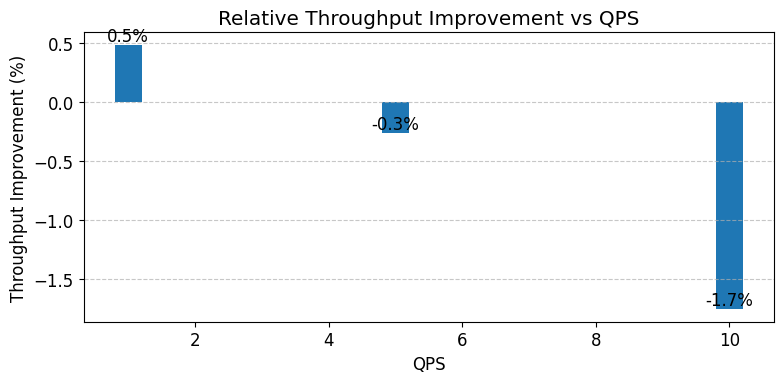

In [6]:
spec_token_throughput = [630,2270,3094]
nospec_token_throughput = [627,2276,3149] # 100 qingqiu
qps = [1,5,10]
# 计算delta值
delta = [(spec - nospec)/nospec*100 for spec,nospec in zip(spec_token_throughput,nospec_token_throughput)]

plt.figure(figsize=(8,4))

# 设置字体大小
plt.rcParams.update({'font.size': 12})

# 创建柱状图
bars = plt.bar(qps, delta, width=0.4)

# 在柱子上方添加百分比标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')

# 添加标签和标题
plt.xlabel('QPS')
plt.ylabel('Throughput Improvement (%)')
plt.title('Relative Throughput Improvement vs QPS')

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局
plt.tight_layout()

plt.show()



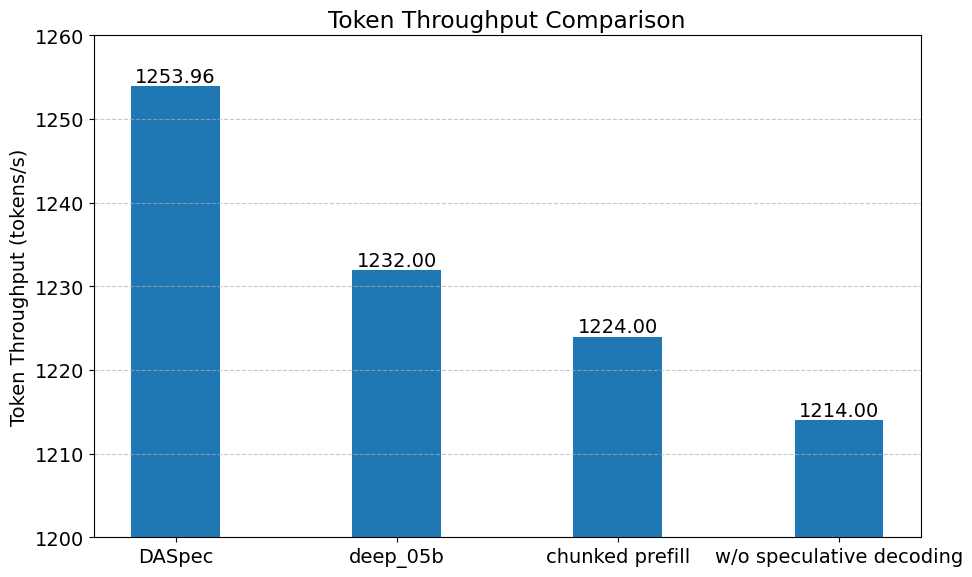

In [6]:
output_throughput = [1253.96,1232,1224, 1214]
x_labels = ['DASpec','deep_05b','chunked prefill','w/o speculative decoding']
plt.figure(figsize=(10,6))

# 设置字体大小
plt.rcParams.update({'font.size': 14})

# 创建柱状图 - 设置宽度为0.4使柱子更细
bars = plt.bar(x_labels, output_throughput, width=0.4)

# 在柱子上方添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

# 添加标签和标题
plt.ylabel('Token Throughput (tokens/s)')
plt.title('Token Throughput Comparison')

# 设置y轴范围以突出差异
plt.ylim(1200, 1260)  # 从1200开始而不是0，放大差异

# 添加网格线使差异更明显
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 在图表中标注y轴被截断
# plt.text(0, 1202, '↓ y轴从1200开始 ↓', ha='left', va='bottom', fontsize=10)

# 调整布局
plt.tight_layout()

plt.show()




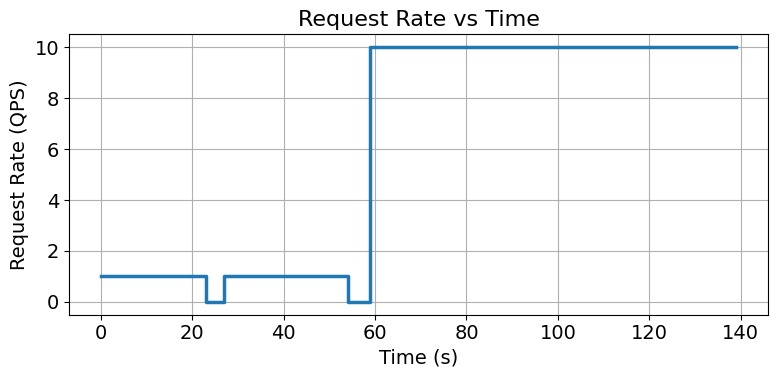

In [13]:
times = [23,4,27,5,80]
qps = [1,0,1,0,10]
import matplotlib.pyplot as plt
import numpy as np

# 计算每段的起始时间点
start_points = [0]
for t in times[:-1]:
    start_points.append(start_points[-1] + t)

# 创建x轴和y轴数据点
x = []
y = []
for i in range(len(times)):
    x.extend([start_points[i], start_points[i] + times[i]])
    y.extend([qps[i], qps[i]])

plt.figure(figsize=(8,4))  # 减小图片尺寸
plt.plot(x, y, '-', linewidth=2.5)  # 增加线条粗细

# 添加标签和标题
plt.xlabel('Time (s)', fontsize=14)  # 增大字体
plt.ylabel('Request Rate (QPS)', fontsize=14)  # 增大字体
plt.title('Request Rate vs Time', fontsize=16)  # 增大标题字体

plt.grid(True)
plt.tight_layout()  # 减少边缘空白
plt.show()



In [5]:
import json

def read_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

# 使用示例
file_path = '../question.jsonl'
data = read_jsonl(file_path)
data[0]['turns'][0]

'Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.'

1. 硬件感知 budget
2. 温度自适应  top k 或者 独立重分布 无重放 NO
3. batch
4. 长短文本 短测数据比较有效
5. 请求调度 优先级的问题
6. 异步
7. 禁用，动态卸载, 有两种原因是需要offload的，一个是超出长度，一个是batch size很大
8. 多proposer https://github.com/vllm-project/vllm/pull/7947